# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [1]:
from __future__ import annotations

import torch
from torch import nn

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [2]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        # TODO: initialize parameters
        self.weight = nn.Parameter(torch.zeros(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None
        torch.nn.init.xavier_uniform_(self.weight, gain=1.0)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        # TODO: implement
        out = torch.einsum("o i, ... i -> ... o", self.weight, x)
        if self.bias is not None:
            return out + self.bias
        else:
            return out


In [3]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        # TODO: initialize
        self.embedding = nn.Parameter(nn.init.xavier_uniform(torch.zeros(num_embeddings, embedding_dim)))
        self.num_embeddings = num_embeddings

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        # TODO: implement (index into weight)
        return self.embedding[idx]


In [4]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        # TODO: implement without using nn.Dropout
        if self.train:
            mask = (torch.rand_like(x) > self.p).to(x.dtype)
            return x * mask * (1 / (1 - self.p))
        else:
            return x
        

## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [5]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        # TODO: implement
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        # TODO: implement
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True)
        normalized = (x - mean) / torch.sqrt(var + self.eps)
        return normalized * self.weight + self.bias

In [6]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        # TODO: implement
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        # TODO: implement
        normalized = x / torch.sqrt((x**2).mean(dim=-1, keepdim=True) + self.eps)
        return normalized * self.weight

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [7]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        # TODO: build modules (list of Linear + activation)
        # Optionally insert LayerNorm between layers.
        layers = []
        current_in_dim = in_dim
        for i in range(depth):
            current_out_dim = out_dim if i == depth - 1 else hidden_dim
            layers.append(Linear(current_in_dim, current_out_dim))
            if use_layernorm:
                layers.append(LayerNorm(current_out_dim))
            layers.append(nn.GELU())

            current_in_dim = current_out_dim
        
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        return self.network(x)

In [8]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        # TODO: create two Linear layers and choose an activation (GELU)
        self.ff = MLP(d_model, d_ff, d_model, 2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        return self.ff(x)

In [9]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        # TODO: implement
        self.fn = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        # TODO: return x + fn(x, ...)
        return x + self.fn(x, *args, **kwargs)

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [10]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [11]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

batch_size = 64

# TODO: define the dataloaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size)

In [30]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    # TODO: implement
    probs = nn.functional.log_softmax(logits, dim=-1)
    return -probs[torch.arange(logits.shape[0]), targets].sum() / logits.shape[0]


In [13]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        # TODO: implement
        self.linear = Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        # TODO: implement
        return self.linear(x)

In [25]:
def accuracy(loader):
    # TODO: You can use this function to evaluate your model accuracy.
    model.eval()
    guesses = []
    with torch.no_grad():
        for x, y in loader:
            x = x.squeeze()
            out = model(x.flatten(start_dim=-2))
            y_out = out.argmax(dim=-1)

            guesses.append(y_out == y)

    model.train()
    return torch.cat(guesses).float().mean().item()



In [29]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """
    # TODO: implement
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    accuracies = []
    losses = []
    for epoch in range(epochs):
        for x, y in train_data_loader:
            x = x.squeeze()
            optimizer.zero_grad()
            out = model(x.flatten(start_dim=-2))
            loss = cross_entropy_from_logits(out, y)
            loss.backward()
            optimizer.step()

            accuracies.append(accuracy(test_data_loader))
            losses.append(loss.item())

            # Reporting every 100 steps:
            if len(losses) % 100 == 0:
                print(
                    f"Epoch {epoch}, Step {len(losses)}, Loss: {loss.item():.4f}, Test Accuracy: {accuracies[-1]:.4f}"
                )

    return losses, accuracies


Epoch 0, Step 100, Loss: 0.8817, Test Accuracy: 0.7194
Epoch 0, Step 200, Loss: 0.8897, Test Accuracy: 0.7313
Epoch 0, Step 300, Loss: 0.9122, Test Accuracy: 0.7372
Epoch 0, Step 400, Loss: 0.7789, Test Accuracy: 0.7478
Epoch 0, Step 500, Loss: 0.9212, Test Accuracy: 0.7504
Epoch 0, Step 600, Loss: 0.9740, Test Accuracy: 0.7530
Epoch 0, Step 700, Loss: 0.6844, Test Accuracy: 0.7540
Epoch 0, Step 800, Loss: 0.7841, Test Accuracy: 0.7549
Epoch 0, Step 900, Loss: 0.6099, Test Accuracy: 0.7583
Epoch 1, Step 1000, Loss: 0.6958, Test Accuracy: 0.7586
Epoch 1, Step 1100, Loss: 0.5341, Test Accuracy: 0.7569
Epoch 1, Step 1200, Loss: 0.5177, Test Accuracy: 0.7606
Epoch 1, Step 1300, Loss: 0.6712, Test Accuracy: 0.7620
Epoch 1, Step 1400, Loss: 0.5084, Test Accuracy: 0.7777
Epoch 1, Step 1500, Loss: 0.8847, Test Accuracy: 0.8056
Epoch 1, Step 1600, Loss: 0.4128, Test Accuracy: 0.8061
Epoch 1, Step 1700, Loss: 0.5705, Test Accuracy: 0.8247
Epoch 1, Step 1800, Loss: 0.7549, Test Accuracy: 0.8386


Matplotlib is building the font cache; this may take a moment.


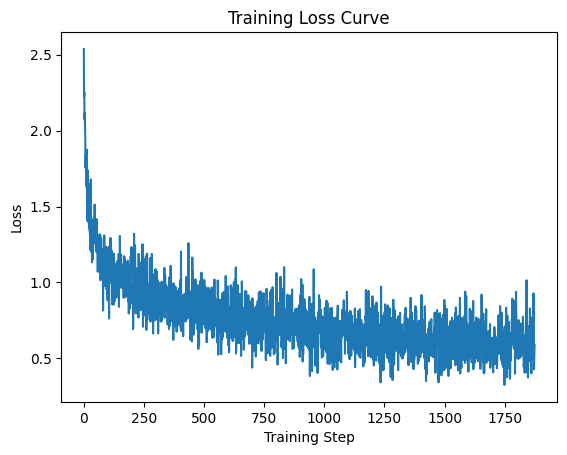

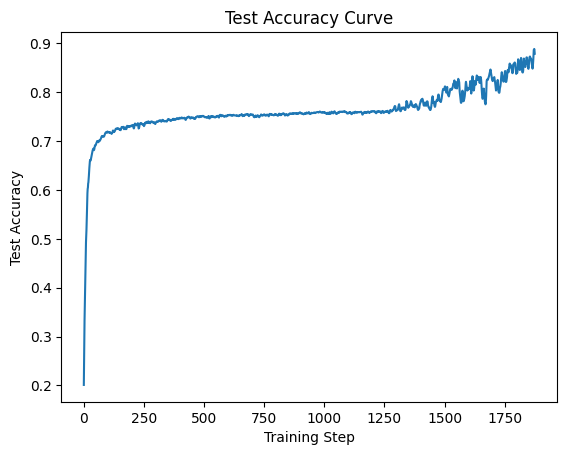

In [32]:
learning_rate = 1e-3
num_epochs = 2
model = MLP(28 * 28, 128, 10, depth=2, use_layernorm=True)

losses, accuracies = train_classifier(
    model, train_loader, test_loader, learning_rate, num_epochs
)

import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

plt.plot(accuracies)
plt.xlabel("Training Step")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Curve")
plt.show()

In [33]:
final_accuracy = accuracies[-1]
print(f"Final Test Accuracy: {final_accuracy:.4f}")

Final Test Accuracy: 0.8788
